## Cài đặt và Đăng nhập

In [ ]:
!pip install -q transformers[torch] datasets pyvi accelerate huggingface_hub

from huggingface_hub import notebook_login
# Dán Token (quyền WRITE) từ Hugging Face vào đây
notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Chuẩn bị dữ liệu từ Hugging Face Hub

In [ ]:
import pandas as pd
from datasets import load_dataset
from pyvi import ViTokenizer
from transformers import AutoTokenizer

# Tải dataset
dataset_id = "pqthinh232/vietnamese-restaurant-review-sentiment-dataset"
raw_datasets = load_dataset(dataset_id)

# Cấu hình Tokenizer
model_checkpoint = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Hàm tiền xử lý (Tách từ + Tokenize)
def preprocess_function(examples):
    # Tách từ tiếng Việt cho PhoBERT
    texts = [ViTokenizer.tokenize(str(text)) for text in examples["review"]]
    # Mã hóa văn bản thành tokens (giới hạn 256 tokens)
    return tokenizer(texts, truncation=True, padding="max_length", max_length=256)

print("--- Tokenizing for the dataset ---")
tokenized_datasets = raw_datasets.map(preprocess_function, batched=True, remove_columns=["review", "review_id"])

README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.30M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/669k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26170 [00:00<?, ? examples/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

--- Tokenizing for the dataset ---


Map:   0%|          | 0/26170 [00:00<?, ? examples/s]

Map:   0%|          | 0/3271 [00:00<?, ? examples/s]

Map:   0%|          | 0/3272 [00:00<?, ? examples/s]

## Tính toán Trọng số lớp (Class Weights)

In [ ]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Lấy danh sách nhãn từ tập train để tính toán
labels = raw_datasets['train']['label']
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)

# Chuyển thành tensor để đưa vào mô hình
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda")
print(f"Class Weights (Neg, Pos, Neu): {class_weights}")

Class Weights (Neg, Pos, Neu): [1.75378636 0.55040276 1.63144442]


## Xây dựng Custom Trainer (Để xử lý mất cân bằng)

In [ ]:
from transformers import Trainer, AutoModelForSequenceClassification

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Sử dụng CrossEntropyLoss với trọng số lớp
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## Cấu hình Huấn luyện và Metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Tính Accuracy tổng quát
    acc = accuracy_score(labels, predictions)

    # Tính F1-score (Dùng 'macro' để theo dõi sự công bằng giữa các nhãn trong lúc học)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1': f1
    }

In [ ]:
# Tên Repo nhóm muốn đặt trên Hugging Face
repo_name = "HCMUS-phobert-vietnamese-restaurant-sentiment-analysis"

training_args = TrainingArguments(
    output_dir=repo_name,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,              # Chỉ cần chạy 2 Epoch là quá đủ
    weight_decay=0.01,

    eval_strategy="steps",     # Đánh giá theo bước thay vì theo epoch
    eval_steps=200,                  # Cứ 500 bước (steps) thì chạy tập Validation một lần
    save_strategy="steps",           # Lưu mô hình theo bước
    save_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=5,              # Chỉ giữ lại 2 checkpoint tốt nhất để đỡ tốn bộ nhớ Colab
    push_to_hub=True,
    logging_steps=100,
    report_to="none"
)

In [ ]:
# Khởi tạo mô hình
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label={0: "Negative", 1: "Positive", 2: "Neutral"},
    label2id={"Negative": 0, "Positive": 1, "Neutral": 2}
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [ ]:
# Khởi tạo Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

## Chạy Huấn luyện và Đánh giá tập Test

In [ ]:
# 1. Bắt đầu huấn luyện
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
200,0.498175,0.376383,0.873127,0.842399
400,0.393952,0.352112,0.885968,0.854572
600,0.372375,0.526672,0.867625,0.808649
800,0.391677,0.335421,0.867625,0.841131
1000,0.347115,0.314864,0.867013,0.848502
1200,0.393264,0.336132,0.895139,0.864794
1400,0.340412,0.308336,0.882605,0.859163
1600,0.332708,0.288787,0.886885,0.867418
1800,0.298430,0.331483,0.901559,0.875324
2000,0.292293,0.317158,0.869153,0.856275


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4908, training_loss=0.2880284484922157, metrics={'train_runtime': 6044.8426, 'train_samples_per_second': 12.988, 'train_steps_per_second': 0.812, 'total_flos': 1.032851721291264e+16, 'train_loss': 0.2880284484922157, 'epoch': 3.0})

In [ ]:
print(f"The best model: {trainer.state.best_model_checkpoint}")
print(f"The highest F1-score gained: {trainer.state.best_metric}")

The best model: HCMUS-phobert-vietnamese-restaurant-sentiment-analysis/checkpoint-4200
The highest F1-score gained: 0.878618737656863


In [ ]:
# 2. Đánh giá chi tiết trên tập Test (Dành cho báo cáo đồ án)
print("\n--- EVALUATION ON THE TEST SET ---")
test_results = trainer.evaluate(tokenized_datasets["test"])

# In bảng kết quả sạch đẹp
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 30)
for key, value in test_results.items():
    if key.startswith("eval_"):
        name = key.replace("eval_", "")
        print(f"{name:<15} | {value:.4f}")


--- EVALUATION ON THE TEST SET ---


Metric          | Value     
------------------------------
loss            | 0.4611
accuracy        | 0.8863
f1              | 0.8604
runtime         | 49.3853
samples_per_second | 66.2540
steps_per_second | 4.1510


In [ ]:
# 3. Đẩy bản cuối cùng lên Hugging Face Hub
trainer.push_to_hub("Fine-tuned with 32k samples and class weights")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nalysis/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...nalysis/model.safetensors:  30%|##9       |  160MB /  540MB            

CommitInfo(commit_url='https://huggingface.co/pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis/commit/ae4f3f3f78819c86c9b7613c5cc831109005fc92', commit_message='Fine-tuned with 32k samples and class weights', commit_description='', oid='ae4f3f3f78819c86c9b7613c5cc831109005fc92', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis', endpoint='https://huggingface.co', repo_type='model', repo_id='pqthinh232/HCMUS-phobert-vietnamese-restaurant-sentiment-analysis'), pr_revision=None, pr_num=None)

d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


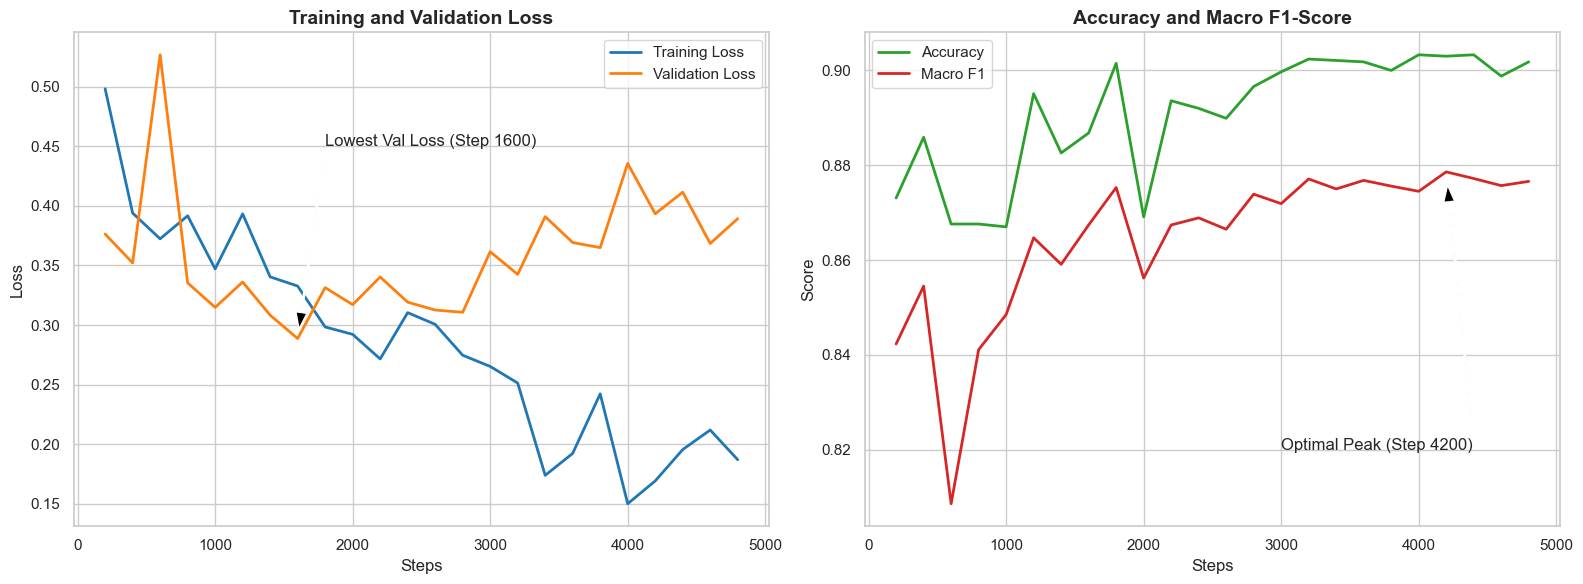

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Trích xuất dữ liệu từ bảng log của nhóm
data = {
    'Step': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800],
    'Train_Loss': [0.4981, 0.3939, 0.3723, 0.3916, 0.3471, 0.3932, 0.3404, 0.3327, 0.2984, 0.2922, 0.2716, 0.3104, 0.3006, 0.2747, 0.2653, 0.2514, 0.1740, 0.1924, 0.2423, 0.1502, 0.1693, 0.1956, 0.2120, 0.1871],
    'Val_Loss': [0.3763, 0.3521, 0.5266, 0.3354, 0.3148, 0.3361, 0.3083, 0.2887, 0.3314, 0.3171, 0.3403, 0.3192, 0.3126, 0.3107, 0.3615, 0.3425, 0.3909, 0.3692, 0.3649, 0.4355, 0.3933, 0.4114, 0.3684, 0.3892],
    'Accuracy': [0.8731, 0.8859, 0.8676, 0.8676, 0.8670, 0.8951, 0.8826, 0.8868, 0.9015, 0.8691, 0.8936, 0.8920, 0.8899, 0.8966, 0.8997, 0.9024, 0.9021, 0.9018, 0.9000, 0.9033, 0.9030, 0.9033, 0.8988, 0.9018],
    'F1_Macro': [0.8423, 0.8545, 0.8086, 0.8411, 0.8485, 0.8647, 0.8591, 0.8674, 0.8753, 0.8562, 0.8674, 0.8689, 0.8665, 0.8739, 0.8719, 0.8771, 0.8750, 0.8768, 0.8756, 0.8745, 0.8786, 0.8772, 0.8757, 0.8766]
}

df = pd.DataFrame(data)
sns.set_theme(style="whitegrid")

# Tạo khung hình gồm 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: LOSS CURVES ---
sns.lineplot(data=df, x='Step', y='Train_Loss', ax=ax1, label='Training Loss', color='#1f77b4', linewidth=2)
sns.lineplot(data=df, x='Step', y='Val_Loss', ax=ax1, label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Steps', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.annotate('Lowest Val Loss (Step 1600)', xy=(1600, 0.2887), xytext=(1800, 0.45),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

# --- BIỂU ĐỒ 2: PERFORMANCE METRICS ---
sns.lineplot(data=df, x='Step', y='Accuracy', ax=ax2, label='Accuracy', color='#2ca02c', linewidth=2)
sns.lineplot(data=df, x='Step', y='F1_Macro', ax=ax2, label='Macro F1', color='#d62728', linewidth=2)
ax2.set_title('Accuracy and Macro F1-Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Steps', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.annotate('Optimal Peak (Step 4200)', xy=(4200, 0.8786), xytext=(3000, 0.82),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.tight_layout()
plt.savefig('phobert_convergence.png', dpi=300)
plt.show()